In [2]:
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error
import pickle

# Load the preprocessed data
df = pd.read_csv('D:/PROGRAMMING/project 2/AirQuality_Cleaned.csv')
# Ensure 'ds' column is in datetime format
df['ds'] = pd.to_datetime(df['ds'], dayfirst=True)

# Dictionary to store results
results = {}

# Define pollutants
pollutants = ['PM2.5', 'PM10', 'Ozone', 'CO', 'Temperature', 'Humidity']

# Loop through each pollutant
for pollutant in pollutants:
    print(f"Training Prophet model for {pollutant}...")

    # Prepare the data for Prophet
    data = df[['ds', pollutant]].rename(columns={pollutant: 'y'}).dropna()

    # Split data into train and test sets
    train = data.iloc[:-100]
    test = data.iloc[-100:]

    # Initialize and fit Prophet model
    model = Prophet()
    model.fit(train)

    # Save the Prophet model for this pollutant
    with open(f'{pollutant}_prophet_model.pkl', 'wb') as file:
        pickle.dump(model, file)

    # Forecast the next 100 periods
    future = model.make_future_dataframe(periods=100)
    forecast = model.predict(future)

    # Extract test forecast values
    forecast_test = forecast.iloc[-100:]['yhat'].values
    test_actual = test['y'].values

    # Calculate error metrics
    mae = mean_absolute_error(test_actual, forecast_test)
    mse = mean_squared_error(test_actual, forecast_test)
    mdape = median_absolute_error(test_actual, forecast_test) / test_actual.mean() * 100
    accuracy = max(0, 100 - mdape)

    # Store results
    results[pollutant] = {
        'MAE': mae,
        'MSE': mse,
        'MdAPE': mdape,
        'Accuracy': accuracy
    }

# Display the results
for pollutant, metrics in results.items():
    print(f"{pollutant}: {metrics}")


d:\PROGRAMMING\project 2\VS\myenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
C:\Users\Aaron\AppData\Local\Temp\ipykernel_9820\1103945493.py:9: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['ds'] = pd.to_datetime(df['ds'], dayfirst=True)


Training Prophet model for PM2.5...


08:58:39 - cmdstanpy - INFO - Chain [1] start processing
08:58:42 - cmdstanpy - INFO - Chain [1] done processing


Training Prophet model for PM10...


08:58:46 - cmdstanpy - INFO - Chain [1] start processing
08:58:49 - cmdstanpy - INFO - Chain [1] done processing


...

Training Prophet model for Temperature...


08:59:01 - cmdstanpy - INFO - Chain [1] start processing
08:59:05 - cmdstanpy - INFO - Chain [1] done processing


Training Prophet model for Humidity...


08:59:07 - cmdstanpy - INFO - Chain [1] start processing
08:59:10 - cmdstanpy - INFO - Chain [1] done processing


PM2.5: {'MAE': 0.14520540818493735, 'MSE': 0.026069367942949805, 'MdAPE': np.float64(34.15859757998162), 'Accuracy': np.float64(65.84140242001838)}
PM10: {'MAE': 0.14562275986388123, 'MSE': 0.02634858774290516, 'MdAPE': np.float64(33.40626224374502), 'Accuracy': np.float64(66.59373775625498)}
Ozone: {'MAE': 0.2536800366420557, 'MSE': 0.09224501554892378, 'MdAPE': np.float64(58.79492354180298), 'Accuracy': np.float64(41.20507645819702)}
CO: {'MAE': 0.2421205299218829, 'MSE': 0.07181194168494642, 'MdAPE': np.float64(39.18435218230695), 'Accuracy': np.float64(60.81564781769305)}
Temperature: {'MAE': 0.2852520637542525, 'MSE': 0.11028836146402159, 'MdAPE': np.float64(50.72605088349611), 'Accuracy': np.float64(49.27394911650389)}
Humidity: {'MAE': 0.35540930960778183, 'MSE': 0.1598750788768108, 'MdAPE': np.float64(56.641423485174904), 'Accuracy': np.float64(43.358576514825096)}


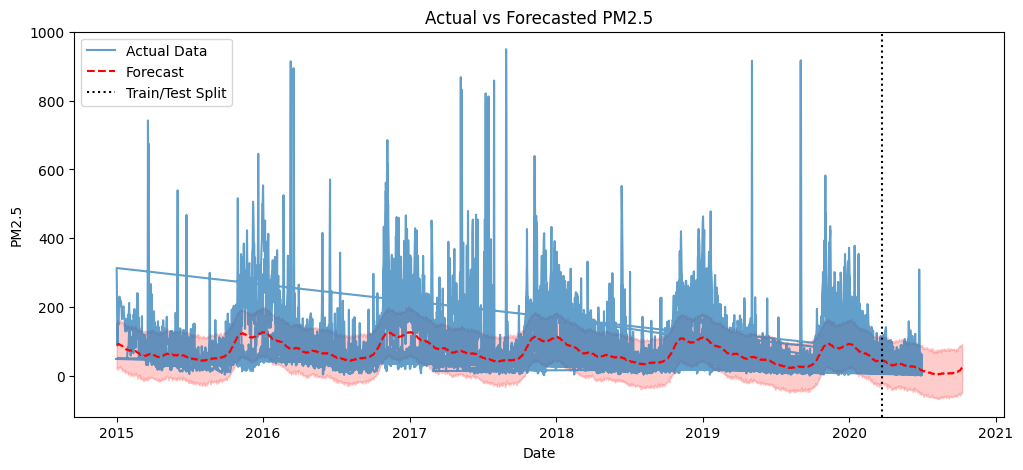

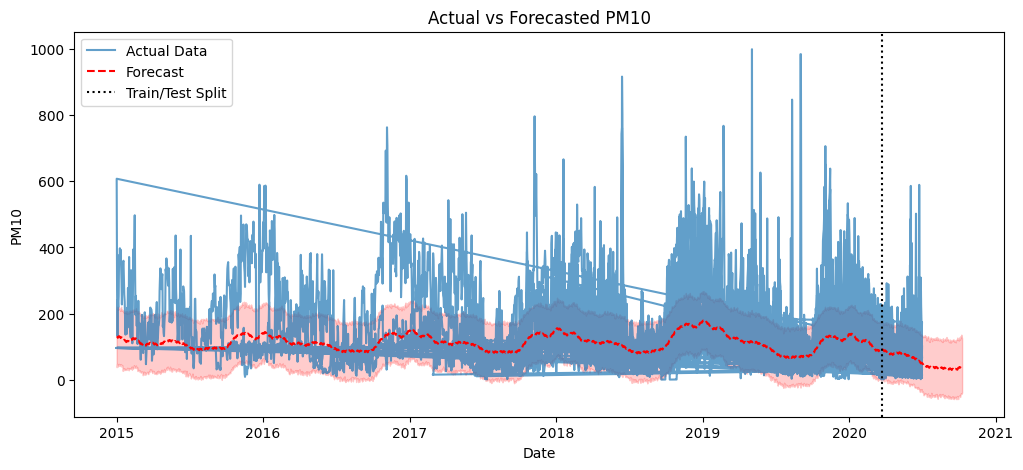

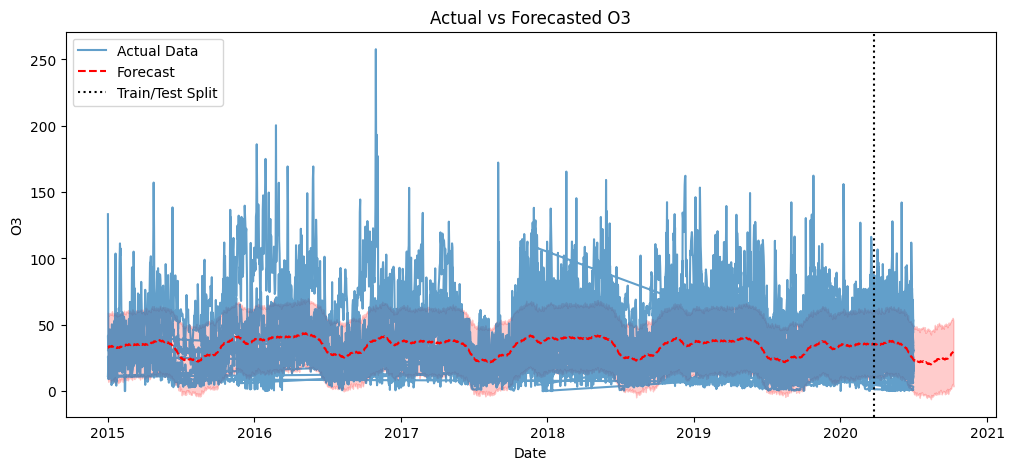

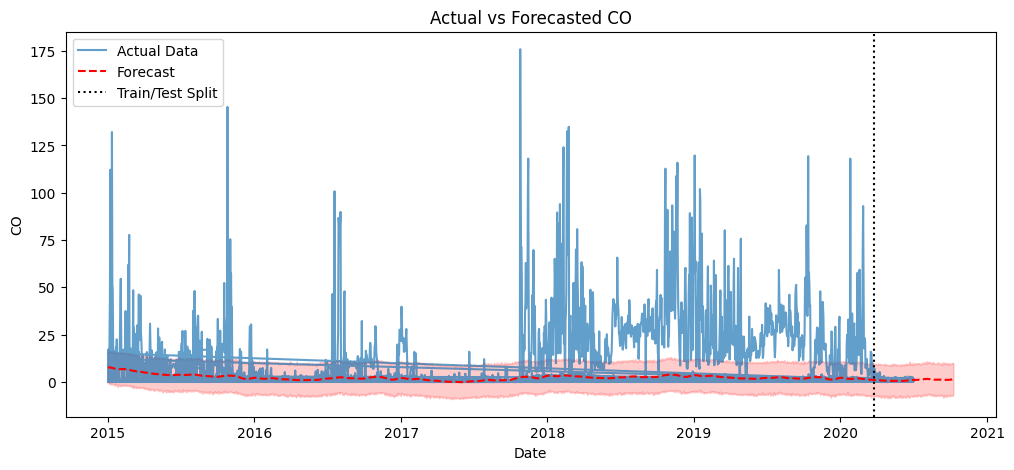

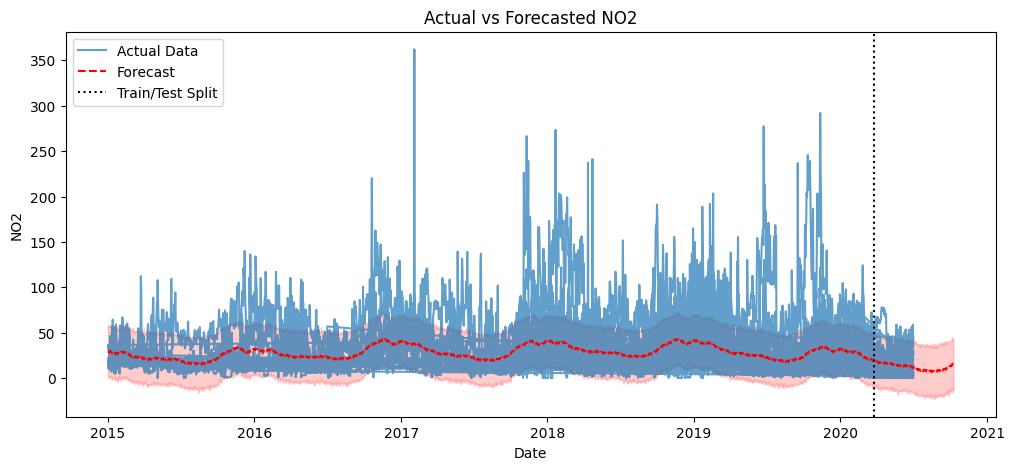

C:\Users\Ashita Singh\AppData\Local\Temp\ipykernel_49868\2060847235.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['MAE'], ax=axes[0], palette="Blues")
C:\Users\Ashita Singh\AppData\Local\Temp\ipykernel_49868\2060847235.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['MSE'], ax=axes[1], palette="Greens")
C:\Users\Ashita Singh\AppData\Local\Temp\ipykernel_49868\2060847235.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['MdAPE'], 

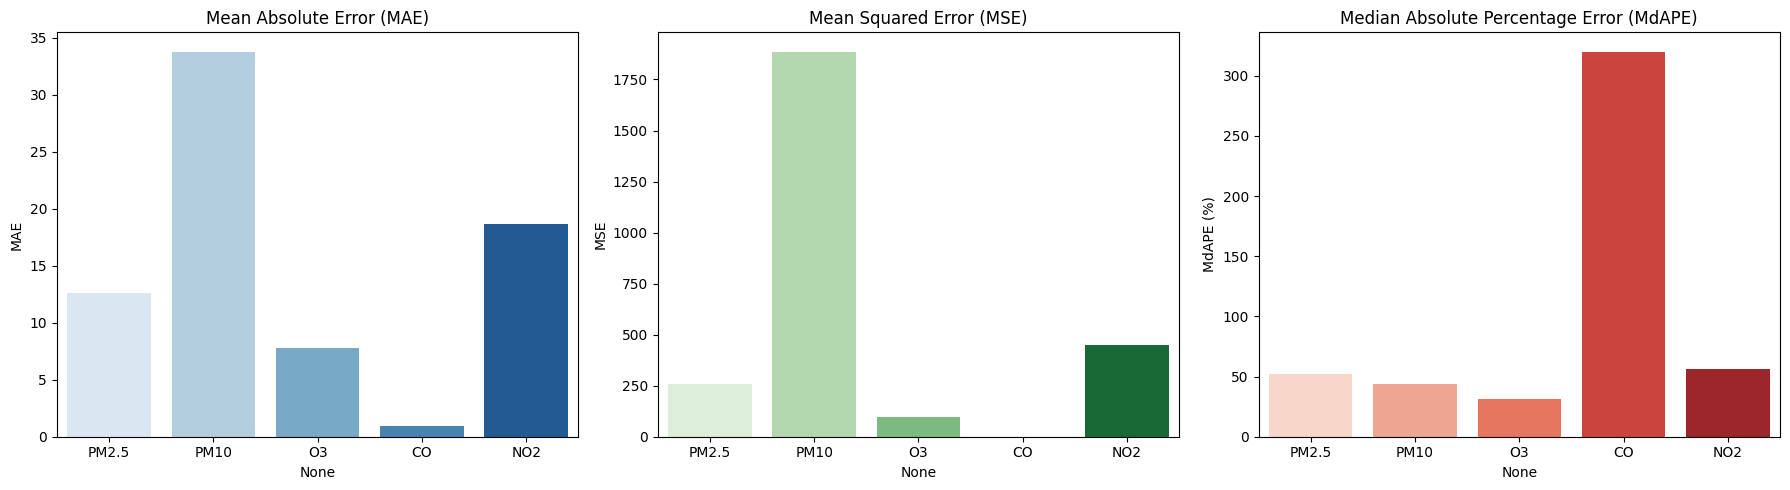

C:\Users\Ashita Singh\AppData\Local\Temp\ipykernel_49868\2060847235.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['Accuracy'], palette="Purples")


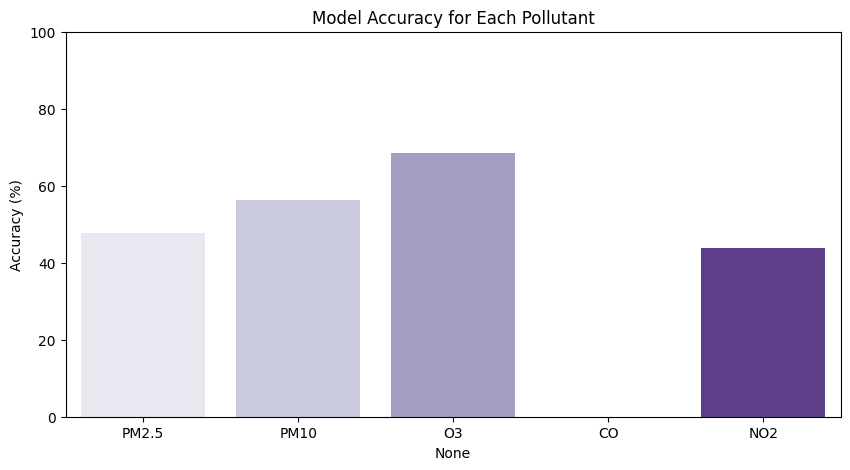

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot actual vs predicted values for each pollutant
for pollutant in pollutants:
    # Load the model
    with open(f'{pollutant}_prophet_model.pkl', 'rb') as file:
        model = pickle.load(file)
    
    # Make future dataframe and predict
    future = model.make_future_dataframe(periods=100)
    forecast = model.predict(future)
    
    # Plot
    plt.figure(figsize=(12, 5))
    plt.plot(df['ds'], df[pollutant], label="Actual Data", alpha=0.7)
    plt.plot(forecast['ds'], forecast['yhat'], label="Forecast", linestyle='dashed', color='red')
    plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='red', alpha=0.2)
    plt.axvline(df['ds'].iloc[-100], color='black', linestyle='dotted', label="Train/Test Split")
    plt.title(f'Actual vs Forecasted {pollutant}')
    plt.xlabel('Date')
    plt.ylabel(pollutant)
    plt.legend()
    plt.show()

# Convert results dictionary to DataFrame for plotting error metrics
results_df = pd.DataFrame(results).T

# Plot error metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MAE
sns.barplot(x=results_df.index, y=results_df['MAE'], ax=axes[0], palette="Blues")
axes[0].set_title("Mean Absolute Error (MAE)")
axes[0].set_ylabel("MAE")

# MSE
sns.barplot(x=results_df.index, y=results_df['MSE'], ax=axes[1], palette="Greens")
axes[1].set_title("Mean Squared Error (MSE)")
axes[1].set_ylabel("MSE")

# MdAPE
sns.barplot(x=results_df.index, y=results_df['MdAPE'], ax=axes[2], palette="Reds")
axes[2].set_title("Median Absolute Percentage Error (MdAPE)")
axes[2].set_ylabel("MdAPE (%)")

plt.tight_layout()
plt.show()

# Plot accuracy comparison
plt.figure(figsize=(10, 5))
sns.barplot(x=results_df.index, y=results_df['Accuracy'], palette="Purples")
plt.title("Model Accuracy for Each Pollutant")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.show()


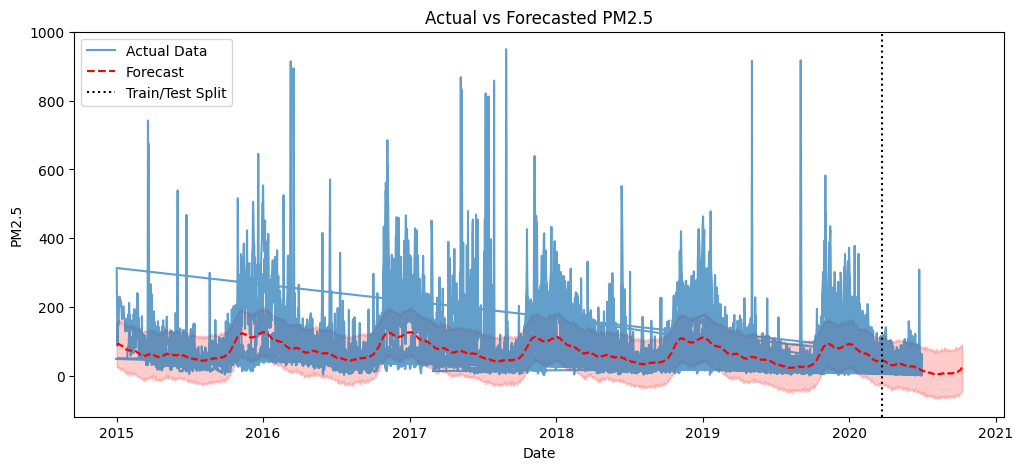

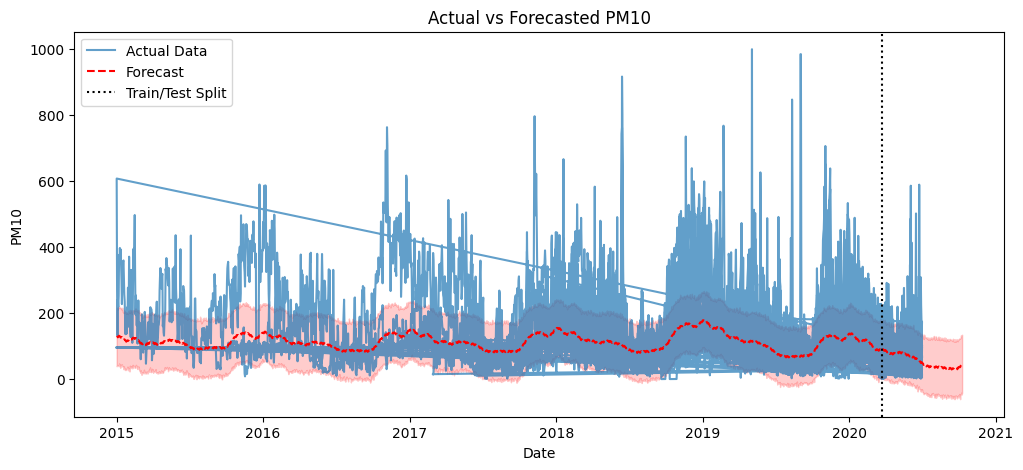

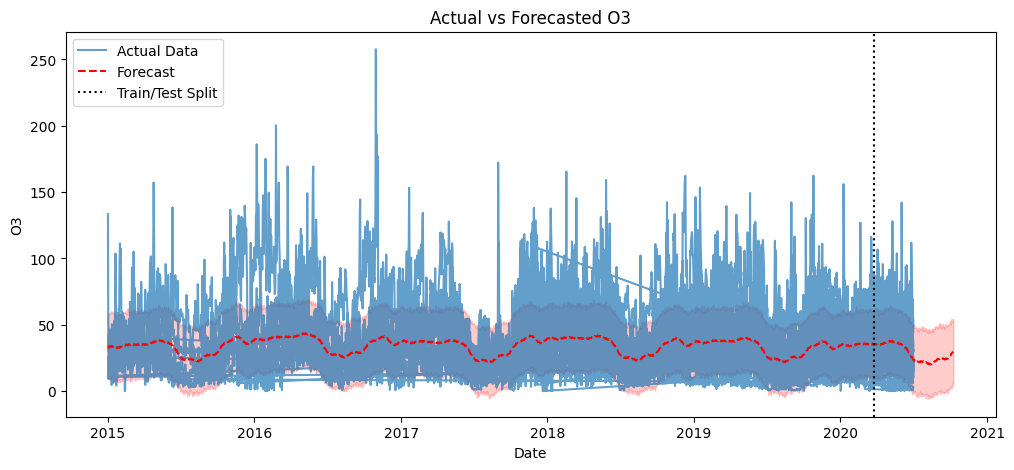

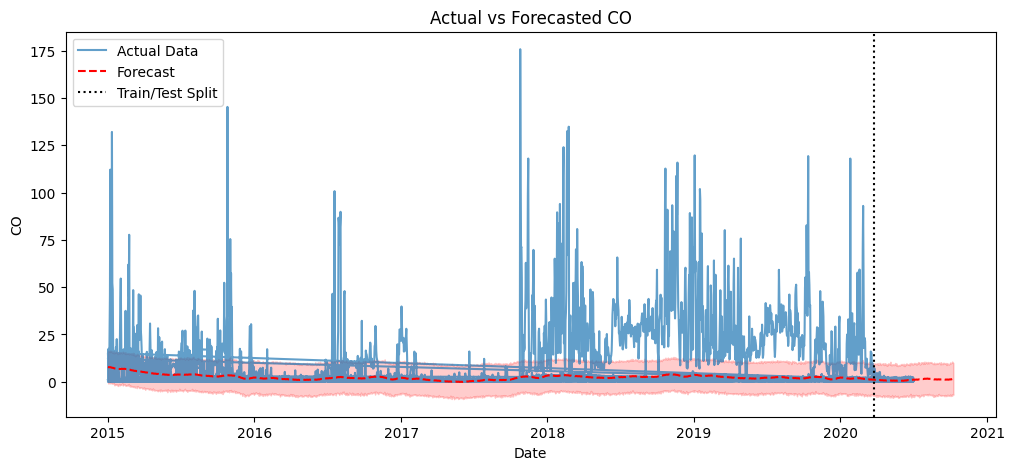

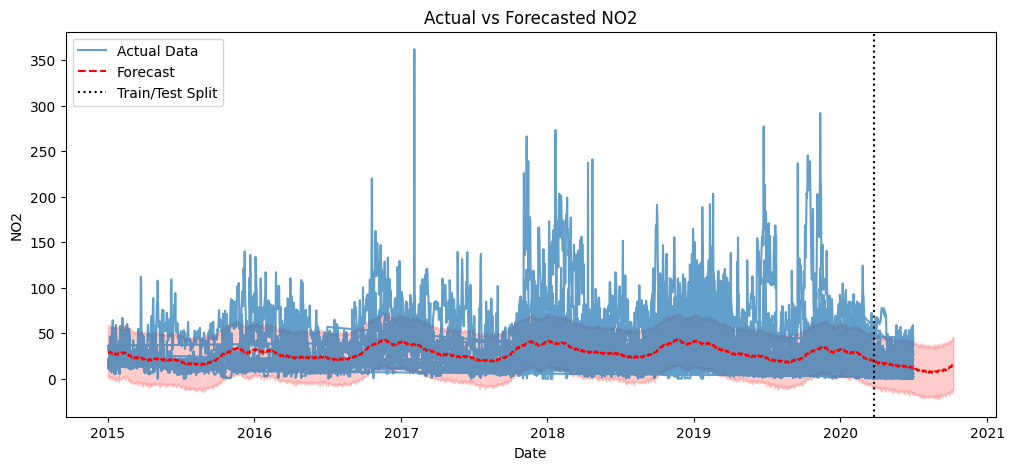

C:\Users\Ashita Singh\AppData\Local\Temp\ipykernel_49868\1725150706.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['MAE'], ax=axes[0], palette="Blues")
C:\Users\Ashita Singh\AppData\Local\Temp\ipykernel_49868\1725150706.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['MSE'], ax=axes[1], palette="Greens")
C:\Users\Ashita Singh\AppData\Local\Temp\ipykernel_49868\1725150706.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['MdAPE'], 

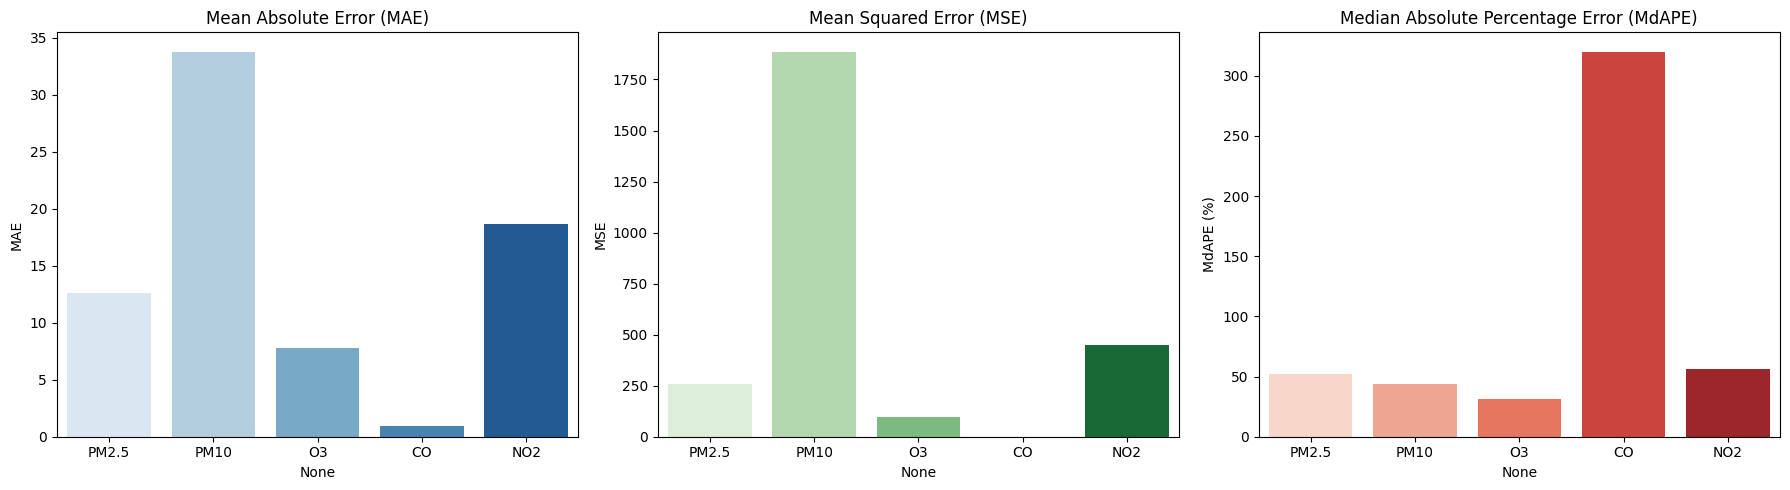

C:\Users\Ashita Singh\AppData\Local\Temp\ipykernel_49868\1725150706.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['Accuracy'], palette="Purples")


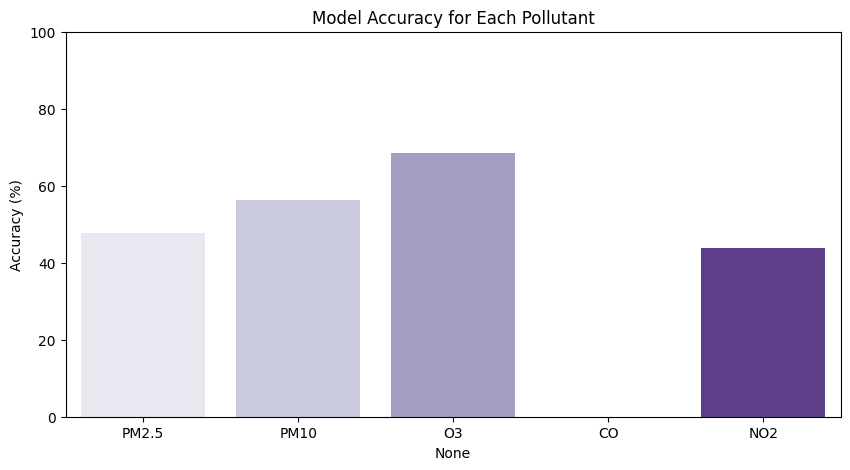

In [17]:
import matplotlib.pyplot as plt 
import seaborn as sns

# Plot actual vs predicted values for each pollutant
for pollutant in pollutants:
    # Load the model
    with open(f'{pollutant}_prophet_model.pkl', 'rb') as file:
        model = pickle.load(file)
    
    # Make future dataframe and predict
    future = model.make_future_dataframe(periods=100)
    forecast = model.predict(future)
    
    # Plot
    
    plt.figure(figsize=(12, 5))
    plt.plot(df['ds'], df[pollutant], label="Actual Data", alpha=0.7)
    plt.plot(forecast['ds'], forecast['yhat'], label="Forecast", linestyle='dashed', color='red')
    plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='red', alpha=0.2)
    plt.axvline(df['ds'].iloc[-100], color='black', linestyle='dotted', label="Train/Test Split")
    plt.title(f'Actual vs Forecasted {pollutant}')
    plt.xlabel('Date')
    plt.ylabel(pollutant)
    plt.legend()
    plt.show()

# Convert results dictionary to DataFrame for plotting error metrics
results_df = pd.DataFrame(results).T

# Plot error metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MAE
sns.barplot(x=results_df.index, y=results_df['MAE'], ax=axes[0], palette="Blues")
axes[0].set_title("Mean Absolute Error (MAE)")
axes[0].set_ylabel("MAE")

# MSE
sns.barplot(x=results_df.index, y=results_df['MSE'], ax=axes[1], palette="Greens")
axes[1].set_title("Mean Squared Error (MSE)")
axes[1].set_ylabel("MSE")

# MdAPE
sns.barplot(x=results_df.index, y=results_df['MdAPE'], ax=axes[2], palette="Reds")
axes[2].set_title("Median Absolute Percentage Error (MdAPE)")
axes[2].set_ylabel("MdAPE (%)")

plt.tight_layout()
plt.show()

# Plot accuracy comparison
plt.figure(figsize=(10, 5))
sns.barplot(x=results_df.index, y=results_df['Accuracy'], palette="Purples")
plt.title("Model Accuracy for Each Pollutant")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.show()